# 04 — Sentiment NLP & Score de Pertinence Final

1. Sentiment NLP sur tweets filtres (cardiffnlp/twitter-roberta-base-sentiment-latest)
2. Predictions celebrites & credibility score
3. Score de pertinence final (ponderation revisee : ai_susceptibility exclu car non predictif)
4. Visualisation quadrant pertinence

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from src.data_loading import load_twitter_sentiment, filter_twitter_programming

SEED = 42
np.random.seed(SEED)
FIGURES = '../reports/figures'

print('Setup OK')

Setup OK


## 1. Sentiment NLP Twitter

In [2]:
train_tw, val_tw = load_twitter_sentiment()
all_tweets = pd.concat([train_tw, val_tw], ignore_index=True)
filtered = filter_twitter_programming(all_tweets)

# Convert Arrow StringDtype to plain object (pandas 3.x compat)
for col in filtered.columns:
    try:
        if str(filtered[col].dtype) in ('string', 'str', 'string[pyarrow_numpy]', 'string[python]'):
            filtered[col] = filtered[col].astype('object')
    except Exception:
        pass

print(f'Tweets filtres : {len(filtered)}')
print(f'sentiment dtype: {filtered["sentiment"].dtype}')
print(filtered['sentiment'].value_counts())

Tweets filtres : 26210
sentiment dtype: object
sentiment
Negative      7787
Positive      7131
Neutral       6446
Irrelevant    4846
Name: count, dtype: int64


In [3]:
# Echantillonnage stratifie si >5000 tweets pour performance CPU
MAX_TWEETS = 5000
if len(filtered) > MAX_TWEETS:
    n_per_group = MAX_TWEETS // filtered['sentiment'].nunique()
    idx = filtered.groupby('sentiment', group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_per_group), random_state=SEED)
    ).index
    sample = filtered.loc[idx].reset_index(drop=True)
    print(f'Echantillon stratifie : {len(sample)}')
else:
    sample = filtered.copy()
    print(f'Pas d\'echantillonnage, {len(sample)} tweets')

print(sample['sentiment'].value_counts())
print(f'Columns: {list(sample.columns)}')

Echantillon stratifie : 5000
sentiment
Irrelevant    1250
Negative      1250
Neutral       1250
Positive      1250
Name: count, dtype: int64
Columns: ['id', 'entity', 'sentiment', 'text']


In [4]:
from transformers import pipeline
import torch

# Use MPS if available, otherwise CPU
if torch.backends.mps.is_available():
    device_str = 'mps'
else:
    device_str = 'cpu'

print(f'Device: {device_str}')

sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=device_str,
    truncation=True,
    max_length=512,
    batch_size=64
)

print('Model loaded')

Device: mps


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded


In [5]:
# Run inference
texts = sample['text'].fillna('').tolist()
results = sentiment_pipe(texts)

# Map labels to numeric: positive=1, neutral=0, negative=-1
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
sample['roberta_label'] = [r['label'] for r in results]
sample['roberta_score'] = [label_map.get(r['label'], 0) for r in results]
sample['roberta_confidence'] = [r['score'] for r in results]

print('RoBERTa sentiment distribution:')
print(sample['roberta_label'].value_counts())

RoBERTa sentiment distribution:
roberta_label
negative    2215
positive    1957
neutral      828
Name: count, dtype: int64


In [6]:
# Match programming languages in tweet text
LANG_PATTERNS = {
    'Python': r'\bpython\b',
    'JavaScript': r'\bjavascript\b',
    'TypeScript': r'\btypescript\b',
    'Java': r'\bjava\b(?!script)',
    'C++': r'\bc\+\+\b',
    'C#': r'\bc#\b|\bcsharp\b',
    'Rust': r'\brust\b',
    'Go': r'\bgolang\b|\bgo lang\b',
    'Ruby': r'\bruby\b',
    'PHP': r'\bphp\b',
    'Swift': r'\bswift\b',
    'Kotlin': r'\bkotlin\b',
    'Scala': r'\bscala\b',
    'R': r'\br lang\b|\brlang\b',
    'MATLAB': r'\bmatlab\b',
    'Perl': r'\bperl\b',
    'Lua': r'\blua\b',
    'Dart': r'\bdart\b',
    'Julia': r'\bjulia\b',
    'Haskell': r'\bhaskell\b',
    'Elixir': r'\belixir\b',
    'Clojure': r'\bclojure\b',
}

# Tag each tweet with detected languages
lang_rows = []
for _, row in sample.iterrows():
    text_lower = str(row['text']).lower()
    for lang, pattern in LANG_PATTERNS.items():
        if re.search(pattern, text_lower):
            lang_rows.append({
                'language': lang,
                'roberta_score': row['roberta_score'],
                'roberta_label': row['roberta_label'],
                'roberta_confidence': row['roberta_confidence'],
            })

lang_sentiment = pd.DataFrame(lang_rows)
print(f'Tweets avec langage detecte : {len(lang_sentiment)}')
print(f'Langages detectes : {lang_sentiment["language"].nunique()}')
print(lang_sentiment['language'].value_counts())

Tweets avec langage detecte : 13
Langages detectes : 6
language
PHP           4
Rust          3
Dart          3
TypeScript    1
Ruby          1
Swift         1
Name: count, dtype: int64


In [7]:
# Compute per-language sentiment metrics
lang_agg = lang_sentiment.groupby('language').agg(
    n_mentions=('roberta_score', 'count'),
    sentiment_mean=('roberta_score', 'mean'),
    sentiment_std=('roberta_score', 'std'),
    pct_positive=('roberta_label', lambda x: (x == 'positive').mean()),
    pct_negative=('roberta_label', lambda x: (x == 'negative').mean()),
    pct_neutral=('roberta_label', lambda x: (x == 'neutral').mean()),
).reset_index()

# sentiment_score = (positive - negative) / total
lang_agg['sentiment_score'] = lang_agg['pct_positive'] - lang_agg['pct_negative']
lang_agg = lang_agg.sort_values('sentiment_score', ascending=False)

print(lang_agg.to_string(index=False))

# Save
lang_agg.to_csv('../data/processed/language_sentiment.csv', index=False)
print(f'\nSaved to data/processed/language_sentiment.csv')

  language  n_mentions  sentiment_mean  sentiment_std  pct_positive  pct_negative  pct_neutral  sentiment_score
      Rust           3            1.00            0.0           1.0          0.00         0.00             1.00
     Swift           1            1.00            NaN           1.0          0.00         0.00             1.00
      Dart           3            0.00            0.0           0.0          0.00         1.00             0.00
       PHP           4           -0.75            0.5           0.0          0.75         0.25            -0.75
      Ruby           1           -1.00            NaN           0.0          1.00         0.00            -1.00
TypeScript           1           -1.00            NaN           0.0          1.00         0.00            -1.00

Saved to data/processed/language_sentiment.csv


## 2. Predictions Celebrities & Credibility Score

In [8]:
celebs = pd.read_csv('../data/raw/predictions_celebrities.csv')
print(f'Predictions : {len(celebs)}')
print(celebs[['auteur', 'langage_concerne', 'prediction', 'realise_oui_non']].to_string(index=False))

# Credibility score par auteur
realise_map = {
    'realise': 1.0,
    'en_cours': 0.5,
    'non_realise': 0.0,
    'non_realise_partiel': 0.25,
}
celebs['score_realise'] = celebs['realise_oui_non'].map(realise_map)

credibility = celebs.groupby('auteur').agg(
    n_predictions=('score_realise', 'count'),
    credibility_score=('score_realise', 'mean'),
).sort_values('credibility_score', ascending=False).reset_index()

print('\n--- Credibility Scores ---')
print(credibility.to_string(index=False))

# Overall credibility
print(f'\nCredibilite globale : {celebs["score_realise"].mean():.2f}')
print(f'Predictions realisees : {(celebs["realise_oui_non"] == "realise").sum()}/{len(celebs)}')
print(f'Predictions non realisees : {celebs["realise_oui_non"].str.startswith("non").sum()}/{len(celebs)}')

Predictions : 15
                auteur langage_concerne            prediction     realise_oui_non
          Jensen Huang          GENERAL decline_coding_manual         non_realise
            Sam Altman          GENERAL      ai_surpasse_devs non_realise_partiel
          Dario Amodei          GENERAL decline_coding_manual         non_realise
         Sundar Pichai          GENERAL            ai_codegen             realise
Prashanth Chandrasekar          GENERAL    decline_so_traffic             realise
       Andrej Karpathy          GENERAL        paradigm_shift            en_cours
       Marc Andreessen          GENERAL       decline_general            en_cours
        Linus Torvalds                C                stable             realise
      Anders Hejlsberg       TypeScript                growth             realise
      Mark Russinovich             Rust                growth            en_cours
      Guido van Rossum           Python      stable_long_term             realise

## 3. Score de Pertinence Final

**Ponderation revisee** (ai_susceptibility exclu car rang 17/21 en SHAP) :

```
pertinence = 0.45 * (1 - prob_decline)     # prediction ML
           + 0.20 * usage_normalise         # taille du marche
           + 0.15 * sentiment_communaute    # signal humain
           + 0.10 * momentum_normalise      # tendance recente
           + 0.10 * stabilite_structurelle  # robustesse
```

In [9]:
import pickle
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Load features panel
df = pd.read_parquet('../data/processed/features_panel_monthly.parquet')

# Get latest observation per language (most recent year_month)
latest = df.sort_values('year_month').groupby('language').last().reset_index()
print(f'Langages avec donnees recentes : {len(latest)}')

# Load best classifier
with open('../models/best_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
print(f'Classifier: {type(clf).__name__}')

Langages avec donnees recentes : 60
Classifier: LogisticRegression


In [10]:
# Feature columns (same as modeling)
feature_cols = [
    'usage_pct', 'delta_1obs', 'delta_3obs', 'delta_6obs', 'delta_12obs',
    'ma_6', 'ma_12', 'volatility_12', 'momentum_6', 'rank',
    'distance_to_peak', 'months_since_peak', 'obs_count',
    'ai_susceptibility_score', 'language_age', 'is_static_typed',
    'is_compiled', 'level_num', 'horizon_num',
    'max_alltime', 'n_observations'
]

available = [c for c in feature_cols if c in latest.columns]
X_latest = latest[available].copy()

# Impute + Scale (same pipeline as training)
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X_latest), columns=available, index=X_latest.index)
scaler = StandardScaler()
X_sc = pd.DataFrame(scaler.fit_transform(X_imp), columns=available, index=X_latest.index)

# Predict probability of decline
latest['prob_decline'] = clf.predict_proba(X_sc)[:, 1]
print('Top 10 prob_decline:')
print(latest[['language', 'prob_decline']].sort_values('prob_decline', ascending=False).head(10).to_string(index=False))

Top 10 prob_decline:
            language  prob_decline
                Perl      0.740911
              VB.NET      0.722758
Delphi/Object Pascal      0.717318
                   C      0.712901
             Fortran      0.695494
               COBOL      0.644009
         Objective-J      0.639767
          AutoHotkey      0.630010
                 PHP      0.624697
        ActionScript      0.622379


In [11]:
# Build pertinence score
score_df = latest[['language', 'usage_pct', 'momentum_6', 'prob_decline',
                     'is_compiled', 'volatility_12']].copy()

# Merge sentiment
sentiment = pd.read_csv('../data/processed/language_sentiment.csv')
score_df = score_df.merge(sentiment[['language', 'sentiment_score', 'n_mentions']],
                          on='language', how='left')

# Normalize components to [0, 1]
mms = MinMaxScaler()

# 1. ML prediction: 1 - prob_decline (higher = more pertinent)
score_df['comp_ml'] = 1 - score_df['prob_decline']

# 2. Usage actuel normalise
score_df['comp_usage'] = mms.fit_transform(score_df[['usage_pct']].fillna(0))

# 3. Sentiment communaute (normalize from [-1, 1] to [0, 1])
score_df['comp_sentiment'] = (score_df['sentiment_score'].fillna(0) + 1) / 2

# 4. Momentum normalise
mom = score_df[['momentum_6']].fillna(0)
score_df['comp_momentum'] = mms.fit_transform(mom)

# 5. Stabilite structurelle (inverse of volatility, higher = more stable)
vol = score_df[['volatility_12']].fillna(score_df['volatility_12'].median())
score_df['comp_stabilite'] = 1 - mms.fit_transform(vol)

# Score final
score_df['pertinence'] = (
    0.45 * score_df['comp_ml'] +
    0.20 * score_df['comp_usage'] +
    0.15 * score_df['comp_sentiment'] +
    0.10 * score_df['comp_momentum'] +
    0.10 * score_df['comp_stabilite']
)

score_df['rang'] = score_df['pertinence'].rank(ascending=False).astype(int)
score_df = score_df.sort_values('pertinence', ascending=False)

print('\n=== TOP 15 LANGAGES A APPRENDRE ===')
print(score_df[['rang', 'language', 'pertinence', 'comp_ml', 'comp_usage',
                'comp_sentiment', 'comp_momentum', 'comp_stabilite']].head(15).to_string(index=False))

print('\n=== BOTTOM 10 LANGAGES A EVITER ===')
print(score_df[['rang', 'language', 'pertinence', 'comp_ml', 'comp_usage',
                'comp_sentiment', 'comp_momentum', 'comp_stabilite']].tail(10).to_string(index=False))


=== TOP 15 LANGAGES A APPRENDRE ===
 rang   language  pertinence  comp_ml  comp_usage  comp_sentiment  comp_momentum  comp_stabilite
    1     Python    0.822803 0.995117    1.000000             0.5       1.000000        0.000000
    2      Swift    0.619380 0.735756    0.093021             1.0       0.395221        0.801637
    3          R    0.618462 0.877028    0.158370             0.5       0.346507        0.824746
    4       Rust    0.610320 0.746194    0.087518             1.0       0.579963        0.490335
    5         C#    0.599561 0.776872    0.230598             0.5       0.427390        0.861104
    6 JavaScript    0.583621 0.880746    0.296635             0.5       0.167279        0.362306
    7     Kotlin    0.579341 0.807108    0.065161             0.5       0.395221        0.885886
    8 PowerShell    0.565315 0.778038    0.031799             0.5       0.375919        0.962462
    9         Go    0.545444 0.754445    0.074104             0.5       0.397059        0.

In [12]:
# Save ranking
score_df.to_csv('../reports/language_pertinence_ranking.csv', index=False)
print(f'Ranking saved : {len(score_df)} langages')

Ranking saved : 60 langages


## 4. Visualisation Quadrant

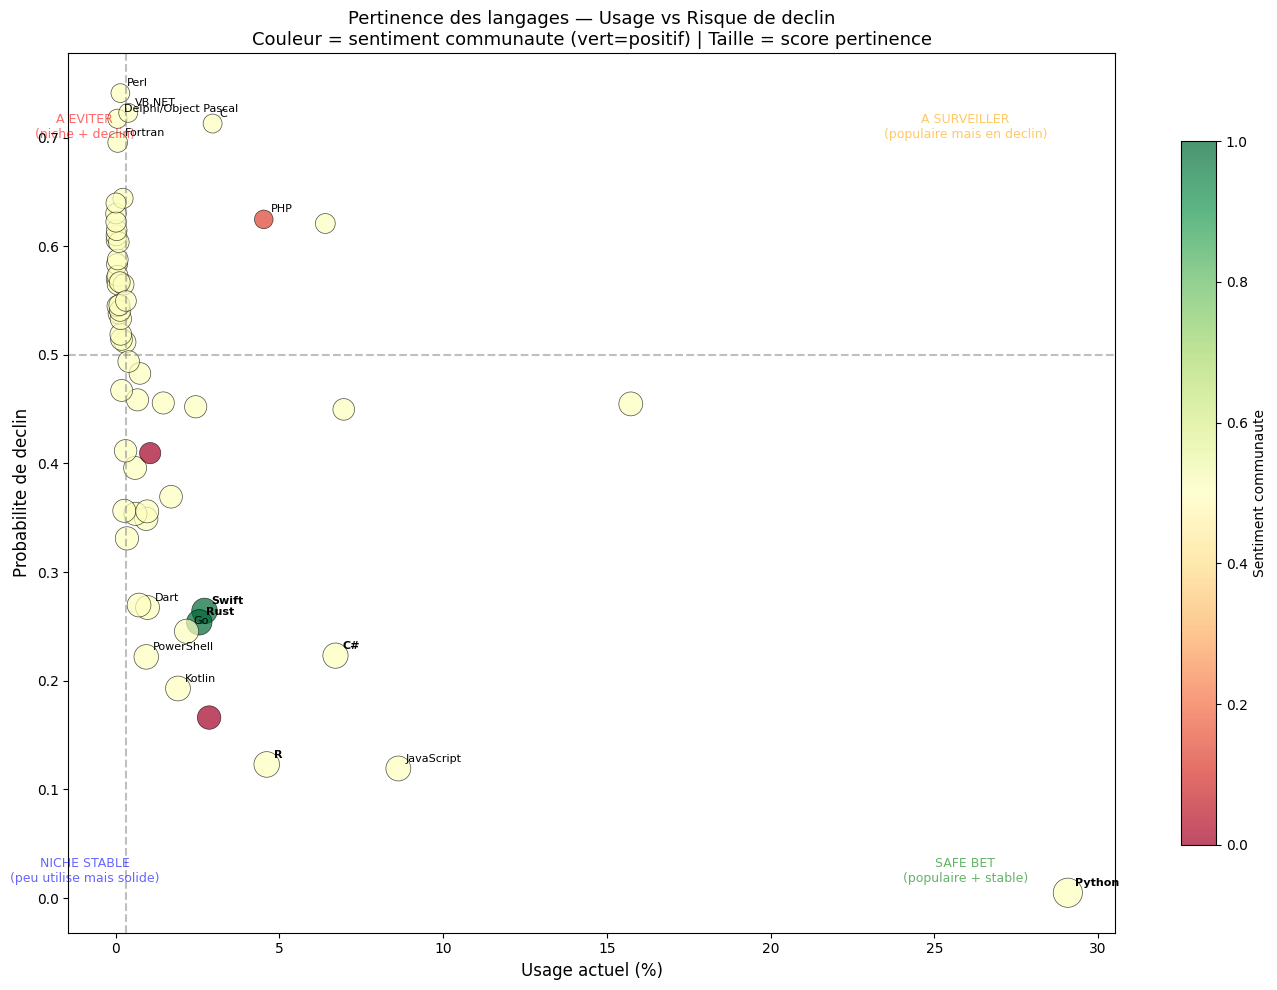

In [13]:
fig, ax = plt.subplots(figsize=(14, 10))

# Color = sentiment (green=positive, red=negative, grey=no data)
colors = score_df['comp_sentiment'].fillna(0.5)

# Size = pertinence score
sizes = score_df['pertinence'] * 500 + 30

scatter = ax.scatter(
    score_df['usage_pct'],
    score_df['prob_decline'],
    c=colors,
    s=sizes,
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Label top/bottom languages
for _, row in score_df.iterrows():
    if row['rang'] <= 10 or row['rang'] >= len(score_df) - 5:
        ax.annotate(
            row['language'],
            (row['usage_pct'], row['prob_decline']),
            fontsize=8, fontweight='bold' if row['rang'] <= 5 else 'normal',
            xytext=(5, 5), textcoords='offset points'
        )

# Quadrant lines
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=score_df['usage_pct'].median(), color='gray', linestyle='--', alpha=0.5)

# Labels
ax.set_xlabel('Usage actuel (%)', fontsize=12)
ax.set_ylabel('Probabilite de declin', fontsize=12)
ax.set_title('Pertinence des langages — Usage vs Risque de declin\n'
             'Couleur = sentiment communaute (vert=positif) | Taille = score pertinence',
             fontsize=13)

# Quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
med_x = score_df['usage_pct'].median()
ax.text(xlim[1]*0.85, ylim[0]*1.1 + 0.05, 'SAFE BET\n(populaire + stable)',
        ha='center', fontsize=9, color='green', alpha=0.6)
ax.text(xlim[0] + 0.5, ylim[0]*1.1 + 0.05, 'NICHE STABLE\n(peu utilise mais solide)',
        ha='center', fontsize=9, color='blue', alpha=0.6)
ax.text(xlim[1]*0.85, ylim[1]*0.9, 'A SURVEILLER\n(populaire mais en declin)',
        ha='center', fontsize=9, color='orange', alpha=0.6)
ax.text(xlim[0] + 0.5, ylim[1]*0.9, 'A EVITER\n(niche + declin)',
        ha='center', fontsize=9, color='red', alpha=0.6)

plt.colorbar(scatter, ax=ax, label='Sentiment communaute', shrink=0.8)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_14_pertinence_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthese

In [14]:
print('=' * 60)
print('SYNTHESE ETAPE 5')
print('=' * 60)

print(f'\n--- Sentiment NLP ---')
print(f'Tweets analyses : {len(sample)}')
print(f'Langages avec sentiment : {len(lang_agg)}')

print(f'\n--- Predictions Celebrities ---')
print(f'Predictions : {len(celebs)}')
print(f'Credibilite moyenne : {celebs["score_realise"].mean():.2f}')

print(f'\n--- Score Pertinence ---')
print(f'Langages scores : {len(score_df)}')
print(f'\nTop 5 :')
for _, r in score_df.head(5).iterrows():
    print(f'  {r["rang"]:2d}. {r["language"]:15s} score={r["pertinence"]:.3f}')
print(f'\nBottom 5 :')
for _, r in score_df.tail(5).iterrows():
    print(f'  {r["rang"]:2d}. {r["language"]:15s} score={r["pertinence"]:.3f}')

print(f'\n--- Choix methodologique ---')
print('ai_susceptibility_score EXCLU du score final')
print('Raison : rang 17/21 en importance SHAP, non predictif du declin')
print('Le score repose sur : ML prediction (45%), usage (20%), sentiment (15%), momentum (10%), stabilite (10%)')

SYNTHESE ETAPE 5

--- Sentiment NLP ---
Tweets analyses : 5000
Langages avec sentiment : 6

--- Predictions Celebrities ---
Predictions : 15
Credibilite moyenne : 0.72

--- Score Pertinence ---
Langages scores : 60

Top 5 :
   1. Python          score=0.823
   2. Swift           score=0.619
   3. R               score=0.618
   4. Rust            score=0.610
   5. C#              score=0.600

Bottom 5 :
  56. Delphi/Object Pascal score=0.320
  57. VB.NET          score=0.312
  58. C               score=0.312
  59. Perl            score=0.305
  60. PHP             score=0.299

--- Choix methodologique ---
ai_susceptibility_score EXCLU du score final
Raison : rang 17/21 en importance SHAP, non predictif du declin
Le score repose sur : ML prediction (45%), usage (20%), sentiment (15%), momentum (10%), stabilite (10%)
